**Dataset:** Weather Type Classification
https://www.kaggle.com/datasets/nikhil7280/weather-type-classification

## Dataset Overview:
The datase contains around 13,000 rows and 11 columns. 
The target variable is **y = Weather Type**
Which contains four possible values: Sunny, Cloudy, Rainy, and Snowy.
The features (X) are: Temperature, Humidity, Wind Speed, Precipitation,
Cloud cover, atmospheric pressure, UV index, season, and location. 

## Hypotheses:
1. Can a type of weather be predicted based on measured atmospheric conditions such as temperature, humidity , wind speed, and atmospheric pressure?
2. Is humidity the strongest influence or predictor of weather type for rain or is there a combination of features, like precipitation percentage and cloud cover, that are more important? 
3. Is a weather type solely based on seasonal patterns or is there a way to predict a weather type using a model without the use of seasons?


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [15]:
df = pd.read_csv('/kaggle/input/datasets/nikhil7280/weather-type-classification/weather_classification_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (13200, 11)


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


## Section 1: Exploratory Data Analysis

In [16]:
print('== Data Types & Non-Null Counts==')
print(df.info())
print('\n==Missing Values==')
print(df.isnull().sum())

== Data Types & Non-Null Counts==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB
None

==Missing Values==
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Clo

In [18]:
df.describe(include='all').round(2)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
count,13200.00,13200.00,13200.00,13200.00,13200,13200.00,13200.00,13200,13200.00,13200,13200
unique,NaN,NaN,NaN,NaN,4,NaN,NaN,4,NaN,3,4
top,NaN,NaN,NaN,NaN,overcast,NaN,NaN,Winter,NaN,inland,Rainy
freq,NaN,NaN,NaN,NaN,6090,NaN,NaN,5610,NaN,4816,3300
mean,19.13,68.71,9.83,53.64,NaN,1005.83,4.01,NaN,5.46,NaN,NaN
std,17.39,20.19,6.91,31.95,NaN,37.20,3.86,NaN,3.37,NaN,NaN
min,-25.00,20.00,0.00,0.00,NaN,800.12,0.00,NaN,0.00,NaN,NaN
25%,4.00,57.00,5.00,19.00,NaN,994.80,1.00,NaN,3.00,NaN,NaN
50%,21.00,70.00,9.00,58.00,NaN,1007.65,3.00,NaN,5.00,NaN,NaN
75%,31.00,84.00,13.50,82.00,NaN,1016.77,7.00,NaN,7.50,NaN,NaN


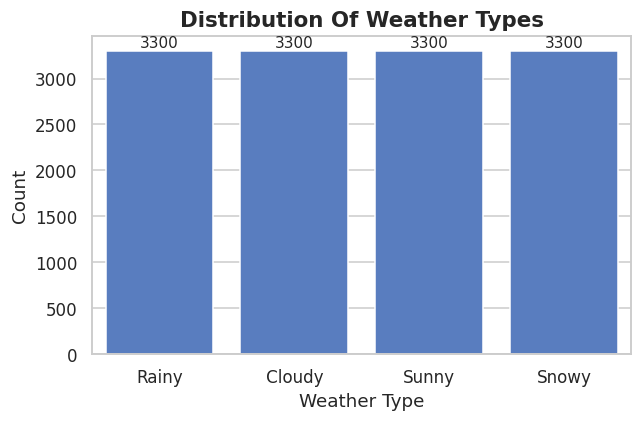

In [19]:
fig, ax = plt.subplots(figsize=(6,4))
order = df['Weather Type'].value_counts().index
sns.countplot(data=df, x='Weather Type', order=order, ax=ax)
ax.set_title('Distribution Of Weather Types', fontsize=14, fontweight='bold')
ax.set_xlabel('Weather Type')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
               (p.get_x() + p.get_width()/2, p.get_height()),
               ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

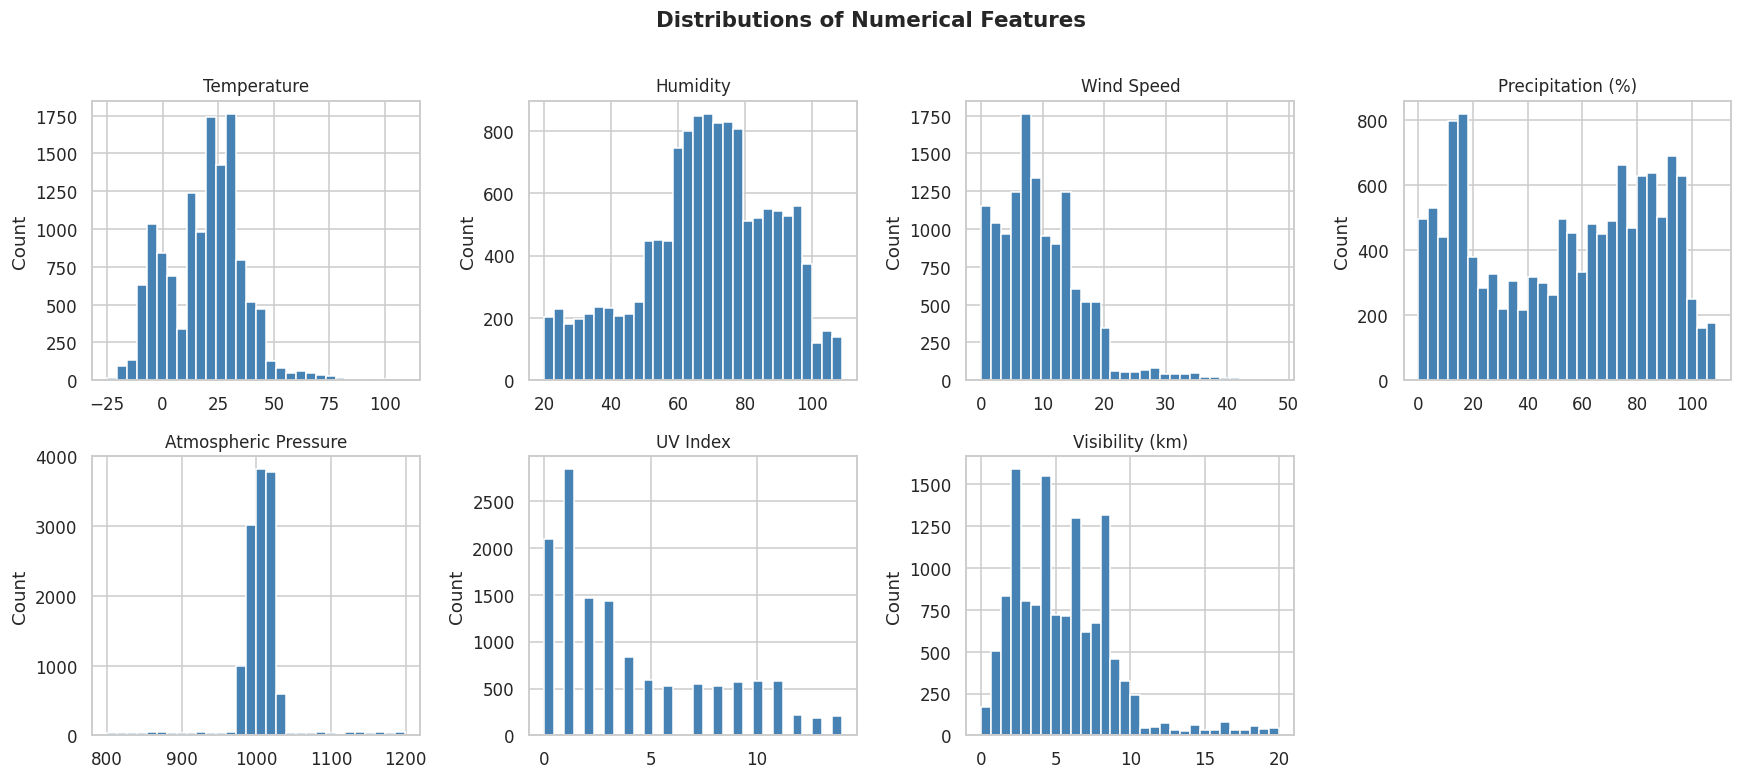

In [21]:
num_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
            'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Count')
axes[-1].set_visible(False)
fig.suptitle('Distributions of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

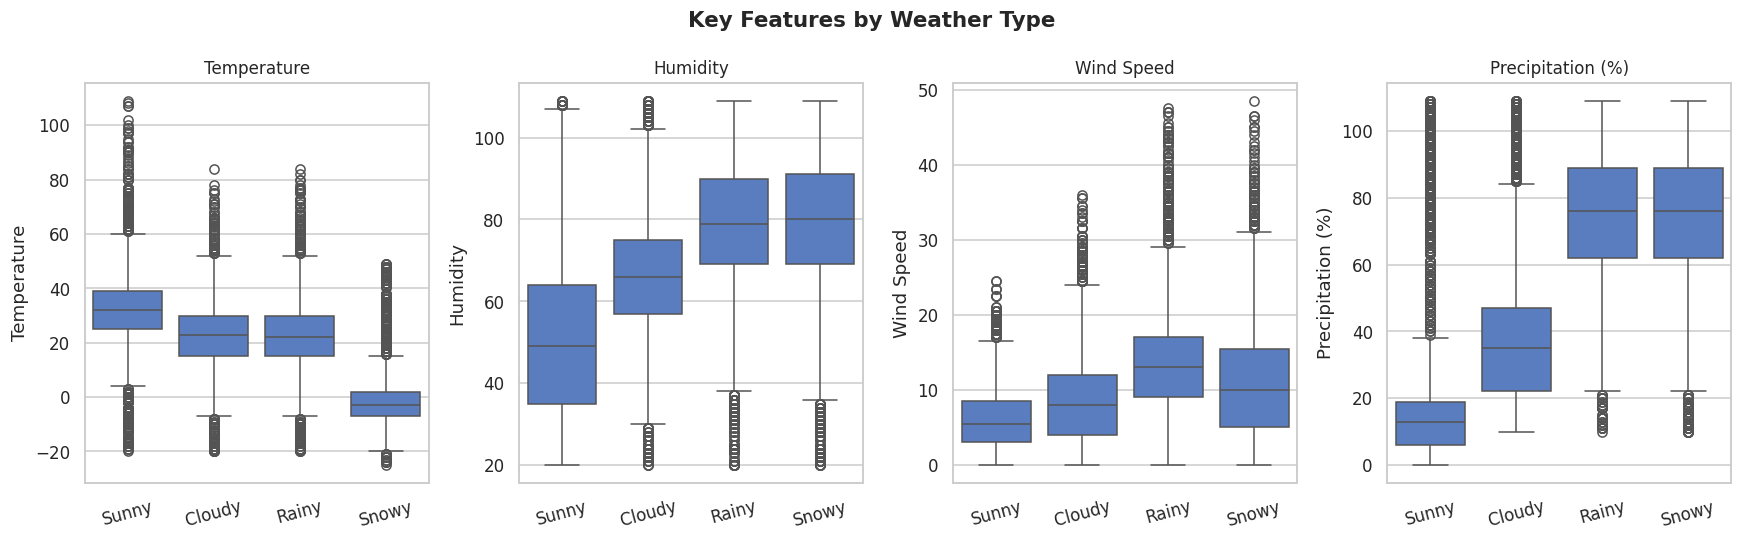

In [22]:
box_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
weather_order = ['Sunny', 'Cloudy', 'Rainy', 'Snowy']

for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df, x='Weather Type', y=col, order=weather_order, ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
fig.suptitle('Key Features by Weather Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

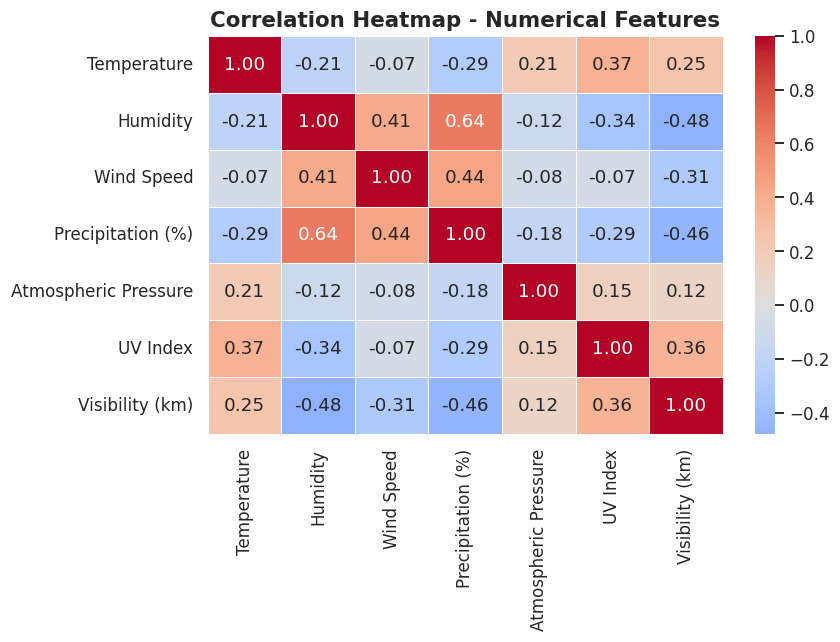

In [24]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

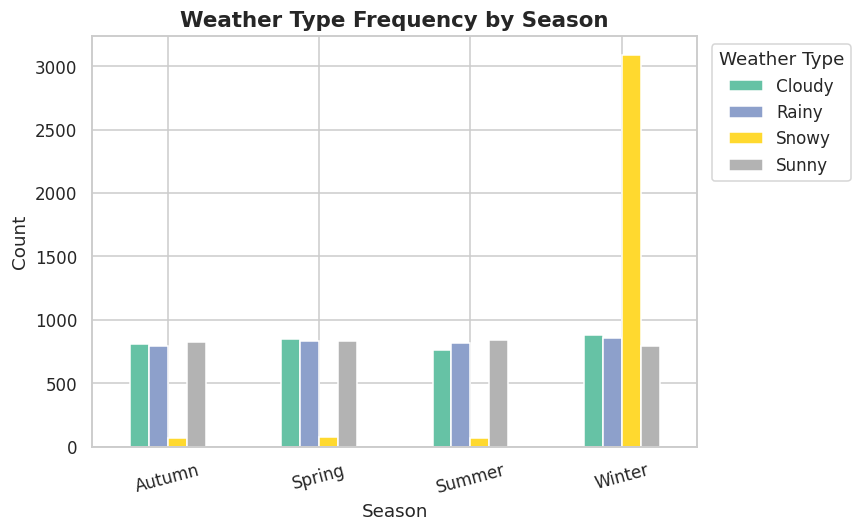

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
season_weather = df.groupby(['Season', 'Weather Type']).size().unstack(fill_value=0)
season_weather.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Weather Type Frequency by Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Weather Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Section 2: Model Fitting

In [33]:
df_model = df.copy()
le = LabelEncoder()

for col in ['Cloud Cover', 'Season', 'Location']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

le_target = LabelEncoder()
df_model['Weather Type'] = le_target.fit_transform(df_model['Weather Type'])
weather_classes = le_target.classes_
print('Weather Type encoding:', dict(enumerate(weather_classes)))

feature_cols = [c for c in df_model.columns if c != 'Weather Type']
X = df_model[feature_cols]
y = df_model['Weather Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Weather Type encoding: {0: 'Cloudy', 1: 'Rainy', 2: 'Snowy', 3: 'Sunny'}

Train: 10560 rows | Test: 2640 rows


In [35]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print(f'Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n')
print(classification_report(y_test, y_pred_lr, target_names=weather_classes))

Logistic Regression Accuracy: 0.8545

              precision    recall  f1-score   support

      Cloudy       0.81      0.83      0.82       660
       Rainy       0.84      0.86      0.85       660
       Snowy       0.90      0.91      0.91       660
       Sunny       0.87      0.81      0.84       660

    accuracy                           0.85      2640
   macro avg       0.86      0.85      0.85      2640
weighted avg       0.86      0.85      0.85      2640



In [36]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f'Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n')
print(classification_report(y_test, y_pred_rf, target_names=weather_classes))

Random Forest Accuracy: 0.9152

              precision    recall  f1-score   support

      Cloudy       0.87      0.92      0.90       660
       Rainy       0.90      0.91      0.91       660
       Snowy       0.95      0.91      0.93       660
       Sunny       0.94      0.92      0.93       660

    accuracy                           0.92      2640
   macro avg       0.92      0.92      0.92      2640
weighted avg       0.92      0.92      0.92      2640



In [46]:
lr_cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                       X_train_sc, y_train, cv=5, scoring='accuracy')
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), 
                       X_train, y_train, cv=5, scoring='accuracy')

print(f'Logistic Regression: {lr_cv.mean():.4f}')
print(f'Random Forest: {rf_cv.mean():.4f}')

Logistic Regression: 0.8576
Random Forest: 0.9157


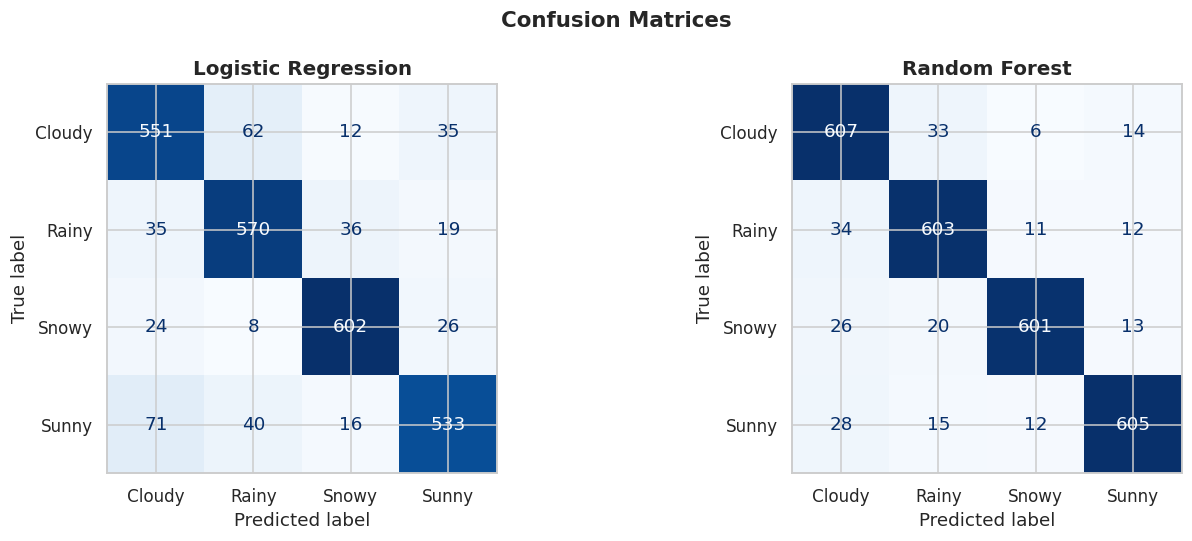

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, title in zip(axes, [y_pred_lr, y_pred_rf], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=weather_classes).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')
    
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

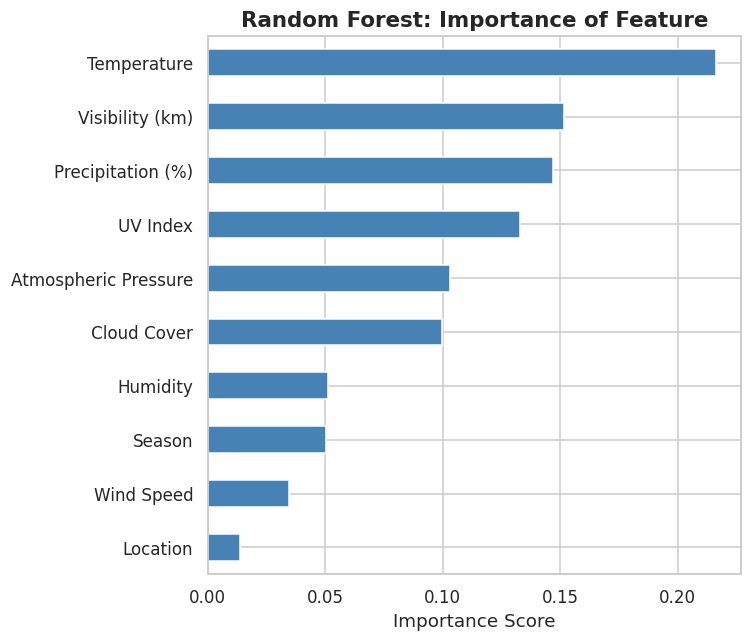

In [42]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest: Importance of Feature', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [43]:
no_season_cols = [c for c in feature_cols if c != 'Season']
X_ns_train = X_train[no_season_cols]
X_ns_test  = X_test[no_season_cols]

rf_no_season = RandomForestClassifier(n_estimators=100, random_state=42)
rf_no_season.fit(X_ns_train, y_train)
acc_no_season = accuracy_score(y_test, rf_no_season.predict(X_ns_test))
acc_with_season = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest WITH Season:    {acc_with_season:.4f}')
print(f'Random Forest WITHOUT Season: {acc_no_season:.4f}')
print(f'Difference: {acc_with_season - acc_no_season:+.4f}')

Random Forest WITH Season:    0.9152
Random Forest WITHOUT Season: 0.9152
Difference: +0.0000


## Section 3: Conclusion and Implications

### Hypothesis #1
**Can a type of weather be predicted based on measured atmospheric conditions such as temperature, humidity , wind speed, and atmospheric pressure?**

Overall the answer is yes. The random forest model gave an accuracy of around  0.9157, while the logistic regression model gave an accuracy of 0.8576. The random forest model had a higher accuracy since it doesn't assume that there is a linear relationship between all of the data, compared to the logistic regression model. Considering the weather data doesn't really have a linear relationship, it works better with the random forest model rathen than making an educated guess on a line that doesn't exist. So, yes atmospheric conditions are enough to help determine what kind of weather the way will have. 

### Hypothesis #2
**Is humidity the strongest influence or predictor of weather type for rain or is there a combination of features, like precipitation percentage and cloud cover, that are more important?**

While humidity is put as one of the top predictors in the random forest feature importance chart, there are other features or predictors that are ranked at the same level. These would be precipitation and temperature, meaning that yes humidity is important, precipitation, cooler temperatures, and even cloud coverage all play an important role in helping predict rain. So while it can be important, there are other features that are more important than just humidity. 

### Hypothesis #3
**Is a weather type solely based on seasonal patterns or is there a way to predict a weather type using a model without the use of seasons?**

The models were trained without including seasons, and while the accuracy did drop, it wasn't a significantly large drop. Overall the result was that no seasonal patterns aren't what determine weather type but rather there are a lot of features that can predict the seasonal pattern on their own. So it is userful to have as a label for the weather but it isn't a huge impacful thing. Rather I think it is just more of a label that helps us understand the weather patterns. 

### Takeaway
The model that performed the best was the random forest model and helped outline the most important features for weather type predictions, which were: precipitation, humidity, and temperature. While the data was not based on actual data collected, it was based on real life data and shows that machine learning models can be very helpful in weather forcasting and climate analysis. 